In [14]:
# 打开总数据集
import pandas as pd
df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\包含holiday_评论_月份_天气的数据集合2.csv',encoding = 'utf-8-sig')
df1

,comment_time,scence_id,scence_name,Sentiment,outbreak,Positive,Neutral,Negative,new_cityname,low_temperature,high_temperature,weather_type,wind,weather1,weather2,holiday,period,month,comment_detail
0,2022/11/25,223,圆明园,neutral,1,27.513403,51.240921,21.248679,北京,-2,14,晴/多云,西北风3-4级/西北风3-4级,晴,多云,0,5,11,明天就要降温了今天风好大
1,2022/11/25,223,圆明园,negative,1,2.416031,8.446255,89.140707,北京,-2,14,晴/多云,西北风3-4级/西北风3-4级,晴,多云,0,5,11,这样能封一辈子吗病毒没死几个人防疫倒是快把人折磨死了
2,2022/11/25,223,圆明园,neutral,1,43.924150,54.498631,1.580220,北京,-2,14,晴/多云,西北风3-4级/西北风3-4级,晴,多云,0,5,11,圆明园被烧十二年后长春园西洋楼花园门残影摄于公元1873同治十二年
3,2022/11/25,223,圆明园,neutral,1,0.056465,99.927229,0.019305,北京,-2,14,晴/多云,西北风3-4级/西北风3-4级,晴,多云,0,5,11,分享图片
4,2022/11/25,223,圆明园,positive,1,99.985266,0.016083,0.001650,北京,-2,14,晴/多云,西北风3-4级/西北风3-4级,晴,多云,0,5,11,吃完饭坐上坐骑真舒服呀
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314930,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,58.925056,32.101324,8.976624,吐鲁番,-8,0,晴/多云,北风1-2级/北风1-2级,晴,多云,0,6,12,【湖面长满片片“鱼鳞” 博斯腾湖出现冰冻奇观】12月5日，受近期寒潮低温天气影响，博斯腾湖湖...
314931,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,42.487818,33.195922,24.319269,吐鲁番,-8,0,晴/多云,北风1-2级/北风1-2级,晴,多云,0,6,12,候只看到岸边的一点点冰块，今年这么多的冰层我还是第一次见到，风一吹像鱼儿一样在游动，这样奇特...
314932,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,51.249945,23.455395,25.297660,吐鲁番,-8,0,晴/多云,北风1-2级/北风1-2级,晴,多云,0,6,12,的冰随着流动的水面堆积，形成了这一壮观的景象，另外此次寒潮天气使开都河提早出现了冰凌现象。”...
314933,2021/10/26,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,43.162942,43.066442,13.773608,吐鲁番,7,17,晴/晴,北风1-2级/北风1-2级,晴,晴,0,4,10,"""【新疆秋之韵：博斯腾湖芦苇摇曳，水鸟成群】博斯腾湖是中国最大的内陆淡水湖。环湖孕育着60万..."


In [81]:
df1['count'] =1 

In [88]:
df_period_month = df1[['period','month','count']].groupby(['period','month']).count()
df_period_month
df_period_month.to_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\month and period.csv',encoding = 'utf-8')

In [92]:
df_period_month = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\month and period.csv',encoding = 'utf-8')
df_period_month.groupby('period').agg({'count':['mean','median','min','max','std']})

count                                    
                mean   median   min    max           std
period                                                  
0        3467.250000   3413.5  1169   5673   1630.953512
1        1045.500000   1050.5   340   1741    621.107881
2        3682.000000   3643.5   679   7781   2295.892419
3        3810.714286   3714.0  2261   6082   1469.040244
4        9086.166667   5516.0  2482  35585   9418.339989
5       22361.400000  26344.0   698  36041  13149.330222
6        6043.000000   6043.0  6043   6043           NaN

In [60]:
df_period_scence.columns = pd.Series(['period','scence_id'])

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements

In [58]:
df_period_scence.columns

Index([], dtype='object')

In [45]:
df_period_scence[['scence_id','period']].groupby(['period','scence_id']).count()

KeyError: "None of [Index(['scence_id', 'period'], dtype='object')] are in the [columns]"

In [177]:
print(df1.columns)

Index(['comment_time', 'scence_id', 'scence_name', 'Sentiment', 'outbreak',
       'Positive', 'Neutral', 'Negative', 'new_cityname', 'low_temperature',
       'high_temperature', 'weather_type', 'wind', 'weather1', 'weather2',
       'holiday', 'period', 'month', 'comment_detail'],
      dtype='object')


## 先将非结构化数据 → 结构化数据
1. 查看 weather1	weather2都由哪些类别
2. 对不同的类别设置权重

In [178]:
dict_weather_points = {'晴':0,
'多云':0,
'阴':0,
'小雨':0.16,
'小雪':0.16,
'小到中雨':0.24,
'浮尘':0.2,
'雾':0.2,
'雨夹雪':0.16,
'扬沙':0.4,
'小到中雪':0.24,
'阵雪':0.16,
'中雪':0.32,
'中雨':0.32,
'中到大雪':0.41,
'中到大雨':0.41,
'霾':0.34,
'中度霾':0.67,
'阵雨':0.16,
'大雪':0.50,
'大雨':0.50,
'冻雨':0.50,
'雷阵雨':0.67,
'雷阵雨伴有冰雹':0.8,
'沙尘暴':0.6,
'暴雪':0.67,
'暴雨':0.67,
'暴雨到大暴雨':0.75,
'大暴雨':0.84,
'大到暴雪':0.75,
'大到暴雨':0.75,}

In [179]:
df1['weather_point1'] = df1['weather1'].map(dict_weather_points)
df1['weather_point2'] = df1['weather2'].map(dict_weather_points)

In [180]:
df1['weather_point1'].describe()

count    314935.000000
mean          0.064770
std           0.144066
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.840000
Name: weather_point1, dtype: float64

## 找出最低温度和最高温度，讲温度进行归一化

In [181]:
# low_temperature	high_temperature	
df1['low_temperature'].describe()

count    314935.000000
mean         15.219433
std           9.058454
min         -36.000000
25%          10.000000
50%          17.000000
75%          22.000000
max          34.000000
Name: low_temperature, dtype: float64

In [182]:
df1['high_temperature'].describe()

count    314935.000000
mean         24.727760
std           9.100017
min         -24.000000
25%          19.000000
50%          26.000000
75%          32.000000
max          46.000000
Name: high_temperature, dtype: float64

In [183]:
df1['temperature_1'] = (df1['high_temperature'] + 24)/70
#  使用最高温度进行归一化处理的

In [184]:
df1['weather_point'] = (df1['weather_point1'] + df1['weather_point2'])/2

In [185]:
df1

,comment_time,scence_id,scence_name,Sentiment,outbreak,Positive,Neutral,Negative,new_cityname,low_temperature,...,weather1,weather2,holiday,period,month,comment_detail,weather_point1,weather_point2,temperature_1,weather_point
0,2022/11/25,223,圆明园,neutral,1,27.513403,51.240921,21.248679,北京,-2,...,晴,多云,0,5,11,明天就要降温了今天风好大,0.0,0.0,0.542857,0.0
1,2022/11/25,223,圆明园,negative,1,2.416031,8.446255,89.140707,北京,-2,...,晴,多云,0,5,11,这样能封一辈子吗病毒没死几个人防疫倒是快把人折磨死了,0.0,0.0,0.542857,0.0
2,2022/11/25,223,圆明园,neutral,1,43.924150,54.498631,1.580220,北京,-2,...,晴,多云,0,5,11,圆明园被烧十二年后长春园西洋楼花园门残影摄于公元1873同治十二年,0.0,0.0,0.542857,0.0
3,2022/11/25,223,圆明园,neutral,1,0.056465,99.927229,0.019305,北京,-2,...,晴,多云,0,5,11,分享图片,0.0,0.0,0.542857,0.0
4,2022/11/25,223,圆明园,positive,1,99.985266,0.016083,0.001650,北京,-2,...,晴,多云,0,5,11,吃完饭坐上坐骑真舒服呀,0.0,0.0,0.542857,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314930,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,58.925056,32.101324,8.976624,吐鲁番,-8,...,晴,多云,0,6,12,【湖面长满片片“鱼鳞” 博斯腾湖出现冰冻奇观】12月5日，受近期寒潮低温天气影响，博斯腾湖湖...,0.0,0.0,0.342857,0.0
314931,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,42.487818,33.195922,24.319269,吐鲁番,-8,...,晴,多云,0,6,12,候只看到岸边的一点点冰块，今年这么多的冰层我还是第一次见到，风一吹像鱼儿一样在游动，这样奇特...,0.0,0.0,0.342857,0.0
314932,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,51.249945,23.455395,25.297660,吐鲁番,-8,...,晴,多云,0,6,12,的冰随着流动的水面堆积，形成了这一壮观的景象，另外此次寒潮天气使开都河提早出现了冰凌现象。”...,0.0,0.0,0.342857,0.0
314933,2021/10/26,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,43.162942,43.066442,13.773608,吐鲁番,7,...,晴,晴,0,4,10,"""【新疆秋之韵：博斯腾湖芦苇摇曳，水鸟成群】博斯腾湖是中国最大的内陆淡水湖。环湖孕育着60万...",0.0,0.0,0.585714,0.0


## 将sentiment type归一，positive为1， netrual为0.5， negative为0，
## sentiment_score为 positive得分 *0.01  netrual * 0.005 negative 为0

In [186]:
list_sentiment = list(df1['Sentiment'])
len(list_sentiment)

314935

In [251]:
# 逻辑回归做的改变
# positive 1 negative 0 neutral 2
# neutral  negative postive
list_sentiment = list(df1['Sentiment'])
list_sentiment_type = []
for i in list_sentiment:
    if i == 'positive':
        list_sentiment_type.append(1)
    elif i == 'negative':
        list_sentiment_type.append(0)
    else:
        list_sentiment_type.append(2)
df1['sentiment_type'] = list_sentiment_type

In [252]:

# # positive 2 negative 0 neutral 1
# # neutral  negative postive
# list_sentiment = list(df1['Sentiment'])
# list_sentiment_type = []
# for i in list_sentiment:
#     if i == 'positive':
#         list_sentiment_type.append(2)
#     elif i == 'negative':
#         list_sentiment_type.append(0)
#     else:
#         list_sentiment_type.append(1)
# df1['sentiment_type'] = list_sentiment_type

In [279]:
# Positive	Neutral	Negative
df1['sentiment_score'] = df1['Positive']*0.01 +  df1['Neutral']*0.005
# df1['sentiment_score'] 

In [280]:
# import pandas as pd
# df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\结构化数据.csv',encoding = 'utf-8-sig')
# df1

In [281]:
# 将数据按照时间和地点进行汇总，汇总使用mean

# df_temp = df.groupby(['key1','key2']).agg({'data1':'min','data2':'max'})
df1_1 = df1.groupby(['scence_id','comment_time'],as_index=False).agg({'outbreak':'mean',
                                                       'holiday':'mean',
                                                       'period':'mean',
                                                       'month':'mean',
                                                       'temperature_1':'mean',
                                                       'weather_point':'mean',
                                                       'sentiment_type':'mean',
                                                       'sentiment_score':'mean'})

In [282]:
# # 将groupby类型转换为dataframe
# df1_2 = df1_1.to_frame()
df1_1["previous_sentiment_score"] =df1_1["sentiment_score"].shift(1)
df1_1["previous_sentiment_score2"] =df1_1["sentiment_score"].shift(2)
df1_1

,scence_id,comment_time,outbreak,holiday,period,month,temperature_1,weather_point,sentiment_type,sentiment_score,previous_sentiment_score,previous_sentiment_score2
0,0,2021/10/3,1.0,1.0,4.0,10.0,0.800000,0.00,0.000000,0.084658,NaN,NaN
1,0,2021/12/10,1.0,0.0,4.0,12.0,0.628571,0.00,1.000000,0.998145,0.084658,NaN
2,0,2021/12/14,1.0,0.0,4.0,12.0,0.642857,0.00,1.000000,0.997587,0.998145,0.084658
3,0,2022/1/24,1.0,0.0,4.0,1.0,0.542857,0.08,2.000000,0.560943,0.997587,0.998145
4,0,2022/10/1,1.0,1.0,5.0,10.0,0.842857,0.00,1.291667,0.670791,0.560943,0.997587
...,...,...,...,...,...,...,...,...,...,...,...,...
91843,272,2022/9/5,1.0,0.0,5.0,9.0,0.671429,0.16,1.466667,0.654968,0.556580,0.702336
91844,272,2022/9/6,1.0,0.0,5.0,9.0,0.771429,0.00,1.600000,0.421901,0.654968,0.556580
91845,272,2022/9/7,1.0,0.0,5.0,9.0,0.814286,0.00,1.576923,0.556592,0.421901,0.654968
91846,272,2022/9/8,1.0,0.0,5.0,9.0,0.785714,0.00,1.526316,0.633952,0.556592,0.421901


In [283]:
df1_1.to_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\面板-结构化数据.csv',encoding = 'utf-8-sig')

In [258]:
#  df1_1.groupby(['scence_id']).shift(1)


# 以上为数据清洗

In [259]:
# import pandas as pd
# df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\结构化数据.csv',encoding = 'utf-8-sig')
# df1

# 集成随机算法
- 集成随机算法分为bagging和boosting算法两类
1. bagging
- bagging最典型的是随机森林，是多个弱学习器投票的结果
- 分类问题是n个弱学习器投票，回归则是取n个弱学习器的平均值
2. boosting
- 培养精英：对每轮效果好的学习器权重加大
- 重视错误：增加上一轮被学习器判定为错误的权重，减少判定为正确的权重。
3. 以下是对随机森林模型，使用sklearn进行实现
- 分为随机森林分类模型RandomForestClassifier
- 和随机森林回归模型 RandomForestRegressor


# 随机森林
## 随机森林不需要数据归一化处理

In [196]:
# https://blog.csdn.net/qq_42433311/article/details/124319618

## 1. sentiment_type结果为Accuracy: 0.706663763066202
## 2. sentiment_score结果为Accuracy:

In [212]:
df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\面板-结构化数据.csv',encoding = 'utf-8-sig')

## 划分训练集和测试集

In [213]:
# 将 comment_time,scence_id 设为行索引
df2 = df1.set_index(['comment_time','scence_id'])

In [214]:
# 创建指标
# 1 生成移动平均线指标
df2['MA2_sentiment_score'] = df2['sentiment_score'].rolling(2).mean()
df2['MA3_sentiment_score'] = df2['sentiment_score'].rolling(3).mean()
df2['MA5_sentiment_score'] = df2['sentiment_score'].rolling(5).mean()
df2['MA7_sentiment_score'] = df2['sentiment_score'].rolling(7).mean()
df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
# df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
df2 = df2.dropna()
df2['sentiment_score'].describe()

count    91839.000000
mean         0.596267
std          0.208512
min          0.000015
25%          0.492551
50%          0.583746
75%          0.730121
max          1.000015
Name: sentiment_score, dtype: float64

In [215]:
# 设置sentiment_score_class，统计sentiment_score的得分进行分类
list_sentiment_score = list(df2['sentiment_score'])
list_sentiment_score_class = []
for i in list_sentiment_score:
    if i >0.6:
        list_sentiment_score_class.append(2)
    elif i <0.5:
         list_sentiment_score_class.append(1)
    else:
        list_sentiment_score_class.append(0)
df2['sentiment_score_class'] = list_sentiment_score_class

In [216]:
# 划分X和y
import numpy as np
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df2['sentiment_score_class']).astype('int')

In [217]:
# 将数据集拆分为训练集和测试机
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

## 为消除数据差值太大带来的影响，利用StandardScaler进行标准化，突出数据集的特征。

In [218]:
# # 数据标准化 特征标度
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [219]:
# 训练
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=50, criterion='entropy', random_state=42)
classifier.fit(X_train, y_train)
print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[ 0.38449794 -0.99715529 -0.3697519  ...  0.65554485  0.5930768
   0.84110455]
 [ 0.38449794  0.46162268 -0.3697519  ...  1.75745114 -1.48872015
  -0.21412275]
 [ 0.38449794 -0.26776631 -0.3697519  ...  0.55851322 -1.00693964
  -0.4961647 ]
 ...
 [ 0.38449794 -0.89295687 -0.3697519  ...  0.8742112  -1.63363925
  -0.8227579 ]
 [ 0.38449794 -2.56013169 -0.3697519  ...  0.84218394 -2.09566048
  -1.21114288]
 [ 0.38449794 -0.68456001 -0.3697519  ... -0.50068217 -0.51667442
  -0.6934945 ]]
y_train: [2 1 1 ... 0 1 1]


In [220]:
y_train.max()

2

In [221]:
# 预测
y_pred = classifier.predict(X_test)
print("X_test:", X_test)
print("y_pred:", y_pred)


X_test: [[ 0.38449794 -3.08112382 -0.3697519  ...  1.25439319 -1.58731088
  -0.57364907]
 [-2.60079419 -1.72654428 -0.3697519  ... -0.41714516 -0.60047908
  -0.71413117]
 [ 0.38449794 -2.24753641 -0.3697519  ...  1.3392337  -2.03520598
  -0.88555049]
 ...
 [ 0.38449794  0.98261481 -0.3697519  ...  1.9304488   0.7439469
   1.67286822]
 [ 0.38449794  0.35742425 -0.3697519  ... -1.47101444 -0.34236731
  -1.0946729 ]
 [ 0.38449794 -0.78875844 -0.3697519  ... -0.58655646 -0.07377104
  -0.38617267]]
y_pred: [1 0 0 ... 2 0 2]


In [222]:
# 输出结果，confusion matrix, classification report, accuracy
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)
result1 = classification_report(y_test, y_pred)
print("Classification Report:", )
print(result1)
result2 = accuracy_score(y_test, y_pred)
print("Accuracy:", result2)

Confusion Matrix:
[[ 7119   106    91]
 [  552  6891     0]
 [  115     0 12678]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7316
           1       0.98      0.93      0.95      7443
           2       0.99      0.99      0.99     12793

    accuracy                           0.97     27552
   macro avg       0.96      0.96      0.96     27552
weighted avg       0.97      0.97      0.97     27552

Accuracy: 0.9686411149825784


## 1. confusion matrix: 
- 变量为-1（negative）被抽取的值有284+10140+4733=15157， 预测准确的数量为284
- 变量为0(netrual)被抽取的值有494+29143+12131=41768，预测准确的数量为29143
- 变量为1（positive）被抽取的值有437+24303+12816=37556，预测准确的数量为12816

## precision为准确率，recall为召回率，f1-score为precision和recall的调和平均值
- 正确率 = 提取出的正确信息条数 /  提取出的信息条数     
- 召回率 = 提取出的正确信息条数 /  样本中的信息条数    

## accuracy为随机森林的准确性，为45%

## 由上可知，将positive, netrual, negative一起训练的效果不佳。可能是因为样本偏差导致的，negative的样本量太少了

## 分析随机森林特征变量的重要性

In [223]:
importances = classifier.feature_importances_
a = pd.DataFrame()
a['特征'] = X.columns
a['特征重要性'] = importances
a = a.sort_values('特征重要性',ascending = False)
a

,特征,特征重要性
8,MA2_sentiment_score,0.400045
6,previous_sentiment_score,0.363184
9,MA3_sentiment_score,0.125464
7,previous_sentiment_score2,0.059757
1,temperature_1,0.020371
4,month,0.011989
5,weather_point,0.007955
3,period,0.007521
2,holiday,0.002265
0,outbreak,0.001450


# OLS模型：效果巨差

In [238]:
# sentiment_score 与 period
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

x =  df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
y = np.array(df2['sentiment_score']) # 先type后score,两个效果差不多
x= sm.add_constant(x) #添加常数项
est=sm.OLS(y,x)
model=est.fit()#建立最小二乘回归模型
print(model.summary())
# sentiment(it) = 44.6127 -1.3158*outbreak(it),且outbreak对应的p值小于0.05***

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.444e+29
Date:                Thu, 13 Apr 2023   Prob (F-statistic):               0.00
Time:                        22:38:46   Log-Likelihood:             2.7331e+06
No. Observations:               91812   AIC:                        -5.466e+06
Df Residuals:                   91802   BIC:                        -5.466e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# 固定效应模型:模型只剩下weather_point和holiday

In [239]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
df2 = df2.dropna()
# # X = ]]

exog = sm.add_constant(df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']])
grunfeld_fe = PanelOLS(df2['sentiment_score'], exog, entity_effects=True, time_effects=True,drop_absorbed=True)
grunfeld_fe = grunfeld_fe.fit()
print(grunfeld_fe)

# # Coding method 2
# grunfeld_fe = PanelOLS.from_formula("invest ~ value + capital + EntityEffects", data)                          
# print(grunfeld_fe.fit())

ValueError: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.

## 用scikit-learn中自带的分类器将预测结果输出，包括confusion matrix、Classification Report、Accuracy。

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)
result1 = classification_report(y_test, y_pred)
print("Classification Report:", )
print(result1)
result2 = accuracy_score(y_test, y_pred)
print("Accuracy:", result2)


In [ ]:
len(df2['sentiment'] =='positive')

## 模型的评估与使用
### 观察下一天情感值得涨跌情况，1为上升，2为下降

In [ ]:
y_pred = model.predict(X_test)
a = pd.DataFrame()
a['预测值'] = list(y_pred)
a['实际值'] = list(y_test)
a.head()

In [ ]:
# 用predict_proba()函数可以预测属于各个分类的概率
y_pred_proba = model.predict_proba(X_test)
a = pd.DataFrame(y_pred_proba,columns = ['分类为-1的概率','分类为1的概率'])
a.head()

## 查看模型的预测准确度

In [240]:
model.score(X_test,y_test) # 0.8的预测度，比较高

AttributeError: 'OLSResults' object has no attribute 'score'

## 分析特征变量的重要性

In [241]:
importances = model.feature_importances_
a = pd.DataFrame()
a['特征'] = X.columns
a['特征重要性'] = importances
a = a.sort_values('特征重要性',ascending = False)
a

AttributeError: 'OLSResults' object has no attribute 'feature_importances_'

# 机器学习-逻辑回归
- 参考文章： https://blog.csdn.net/fulk6667g78o8/article/details/121276957?ops_request_misc=%257B%2522request%255Fid%2522%253A%2522167860103816800188515220%2522%252C%2522scm%2522%253A%252220140713.130102334..%2522%257D&request_id=167860103816800188515220&biz_id=0&utm_medium=distribute.pc_search_result.none-task-blog-2~all~top_positive~default-2-121276957-null-null.142^v73^insert_down3,201^v4^add_ask,239^v2^insert_chatgpt&utm_term=%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92&spm=1018.2226.3001.4187

In [12]:
import pandas as pd
df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\结构化数据.csv',encoding = 'utf-8-sig')
df1 = df1.dropna()

In [13]:
df1

,Unnamed: 0,comment_time,scence_id,scence_name,Sentiment,outbreak,Positive,Neutral,Negative,new_cityname,...,holiday,period,month,comment_detail,weather_point1,weather_point2,temperature_1,weather_point,sentiment_type,sentiment_score
0,0,2022/11/25,223,圆明园,neutral,1,27.513403,51.240921,21.248679,北京,...,0,5,11,明天就要降温了今天风好大,0.0,0.0,0.542857,0.0,0,0.531339
1,1,2022/11/25,223,圆明园,negative,1,2.416031,8.446255,89.140707,北京,...,0,5,11,这样能封一辈子吗病毒没死几个人防疫倒是快把人折磨死了,0.0,0.0,0.542857,0.0,1,0.066392
2,2,2022/11/25,223,圆明园,neutral,1,43.924150,54.498631,1.580220,北京,...,0,5,11,圆明园被烧十二年后长春园西洋楼花园门残影摄于公元1873同治十二年,0.0,0.0,0.542857,0.0,0,0.711735
3,3,2022/11/25,223,圆明园,neutral,1,0.056465,99.927229,0.019305,北京,...,0,5,11,分享图片,0.0,0.0,0.542857,0.0,0,0.500201
4,4,2022/11/25,223,圆明园,positive,1,99.985266,0.016083,0.001650,北京,...,0,5,11,吃完饭坐上坐骑真舒服呀,0.0,0.0,0.542857,0.0,2,0.999933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314930,314930,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,58.925056,32.101324,8.976624,吐鲁番,...,0,6,12,【湖面长满片片“鱼鳞” 博斯腾湖出现冰冻奇观】12月5日，受近期寒潮低温天气影响，博斯腾湖湖...,0.0,0.0,0.342857,0.0,2,0.749757
314931,314931,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,42.487818,33.195922,24.319269,吐鲁番,...,0,6,12,候只看到岸边的一点点冰块，今年这么多的冰层我还是第一次见到，风一吹像鱼儿一样在游动，这样奇特...,0.0,0.0,0.342857,0.0,2,0.590858
314932,314932,2022/12/6,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,51.249945,23.455395,25.297660,吐鲁番,...,0,6,12,的冰随着流动的水面堆积，形成了这一壮观的景象，另外此次寒潮天气使开都河提早出现了冰凌现象。”...,0.0,0.0,0.342857,0.0,2,0.629776
314933,314933,2021/10/26,224,巴音郭楞蒙古自治州博斯腾湖景区,positive,1,43.162942,43.066442,13.773608,吐鲁番,...,0,4,10,"""【新疆秋之韵：博斯腾湖芦苇摇曳，水鸟成群】博斯腾湖是中国最大的内陆淡水湖。环湖孕育着60万...",0.0,0.0,0.585714,0.0,2,0.646962


In [5]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,314935.0,157467.000000,90914.047851,0.000000,78733.500000,157467.000000,236200.500000,314934.000000
scence_id,314935.0,131.652239,78.649970,0.000000,62.000000,128.000000,196.000000,272.000000
outbreak,314935.0,0.911925,0.283405,0.000000,1.000000,1.000000,1.000000,1.000000
Positive,314935.0,38.148408,34.273060,0.001000,5.436720,28.970265,67.824188,100.001001
Neutral,314935.0,43.149545,34.166661,0.001000,11.669457,36.163494,73.388064,100.001001
Negative,314935.0,18.705048,25.246374,0.001000,0.742544,7.011906,26.812680,100.001001
low_temperature,314935.0,15.219433,9.058454,-36.000000,10.000000,17.000000,22.000000,34.000000
high_temperature,314935.0,24.727760,9.100017,-24.000000,19.000000,26.000000,32.000000,46.000000
holiday,314935.0,0.164640,0.370856,0.000000,0.000000,0.000000,0.000000,1.000000
period,314935.0,3.729493,1.531711,0.000000,3.000000,4.000000,5.000000,6.000000


In [299]:
# 这里我希望将neutral作为对照组，因此sentiment_type变动如下
# neutral  negative postive
list_sentiment = list(df1['Sentiment'])
list_sentiment_type = []
for i in list_sentiment:
    if i == 'positive':
        list_sentiment_type.append(1)
    elif i == 'negative':
        list_sentiment_type.append(0)
    else:
        list_sentiment_type.append(2)
df1['sentiment_type'] = list_sentiment_type

In [300]:
import numpy as np
df2 = df1.set_index(['comment_time','scence_id'])


In [302]:
# # 创建指标
# # 1 生成移动平均线指标
df2['MA2_sentiment_score'] = df2['sentiment_score'].rolling(2).mean()
df2['MA3_sentiment_score'] = df2['sentiment_score'].rolling(3).mean()
# df2['MA5_sentiment_score'] = df2['sentiment_score'].rolling(5).mean()
# df2['MA7_sentiment_score'] = df2['sentiment_score'].rolling(7).mean()
# df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
# # df2['MA10_sentiment_score'] = df2['sentiment_score'].rolling(10).mean()
df2["previous_sentiment_score"] =df2["sentiment_score"].shift(1)
df2["previous_sentiment_score2"] =df2["sentiment_score"].shift(2)
df2

df2 = df2.dropna()

In [303]:
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','MA2_sentiment_score','MA3_sentiment_score','previous_sentiment_score','previous_sentiment_score2']]
# X['intercept'] = 1.0     # 添加截距列
# Y = np.array(df2['sentiment_score_class']).astype('int')

In [304]:
# 划分X和y
import numpy as np
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df2['sentiment_type']).astype('int')

In [305]:
from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

         Current function value: 0.400181
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
outbreak,-5.361468,-2.475564
temperature_1,-11.233758,-4.546505
holiday,-0.502750,-0.126202
period,0.488121,0.250307
month,-0.393267,-0.170907
weather_point,-0.650775,-0.257023
previous_sentiment_score,-37.114449,-20.508261
previous_sentiment_score2,-12.053115,-6.434965
MA2_sentiment_score,50.104023,28.302122
MA3_sentiment_score,29.384978,16.723101


In [306]:
# 第三类相当于是对照组，n分类的只会输出n-1个结果

In [307]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                    Results: MNLogit
========================================================================================
Model:                      MNLogit                 Pseudo R-squared:        0.609      
Dependent Variable:         y                       AIC:                     252098.6159
Date:                       2023-04-15 22:03        BIC:                     252311.8181
No. Observations:           314931                  Log-Likelihood:          -1.2603e+05
Df Model:                   18                      LL-Null:                 -3.2205e+05
Df Residuals:               314911                  LLR p-value:             0.0000     
Converged:                  0.0000                  Scale:                   1.0000     
No. Iterations:             35.0000                                                     
----------------------------------------------------------------------------------------
            y = 0               Coef.    Std.Err.      t      P>|t|    [0.025    0.975] 
----------------------------------------------------------------------------------------
                 outbreak       -5.3615    0.0600   -89.3999  0.0000   -5.4790   -5.2439
            temperature_1      -11.2338    0.0712  -157.7984  0.0000  -11.3733  -11.0942
                  holiday       -0.5028    0.0293   -17.1477  0.0000   -0.5602   -0.4453
                   period        0.4881    0.0115    42.5400  0.0000    0.4656    0.5106
                    month       -0.3933    0.0043   -92.4981  0.0000   -0.4016   -0.3849
            weather_point       -0.6508    0.0868    -7.4975  0.0000   -0.8209   -0.4807
 previous_sentiment_score      -37.1144    0.1313  -282.7593  0.0000  -37.3717  -36.8572
previous_sentiment_score2      -12.0531       nan        nan     nan       nan       nan
      MA2_sentiment_score       50.1040       nan        nan     nan       nan       nan
      MA3_sentiment_score       29.3850       nan        nan     nan       nan       nan
----------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|     [0.025       0.975]  
----------------------------------------------------------------------------------------
                 outbreak  -2.4756      0.0499  -49.5894 0.0000      -2.5734     -2.3777
            temperature_1  -4.5465      0.0585  -77.7837 0.0000      -4.6611     -4.4319
                  holiday  -0.1262      0.0242   -5.2190 0.0000      -0.1736     -0.0788
                   period   0.2503      0.0093   26.9552 0.0000       0.2321      0.2685
                    month  -0.1709      0.0036  -47.1109 0.0000      -0.1780     -0.1638
            weather_point  -0.2570      0.0703   -3.6556 0.0003      -0.3948     -0.1192
 previous_sentiment_score -20.5083      0.1111 -184.6662 0.0000     -20.7259    -20.2906
previous_sentiment_score2  -6.4350  71417.6513   -0.0001 0.9999 -139982.4593 139969.5894
      MA2_sentiment_score  28.3021 142835.3025    0.0002 0.9998 -279923.7465 279980.3508
      MA3_sentiment_score  16.7231 214252.9538    0.0001 0.9999 -419911.3498 419944.7960
========================================================================================

"""

## 逻辑回归模型结果
1. 表1中LLR p-value:	5.9914e-31，说明模型显著
2. 第二张表为相关变量的系数以及t值。显著的有outbreak period month weather_point

## 逻辑回归模型评价

In [308]:
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
# from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)

Precision_score: 0.8319917696257275
Recall_score: 0.8319917696257275
F1_score: 0.8319917696257274


## ROC曲线和AUC

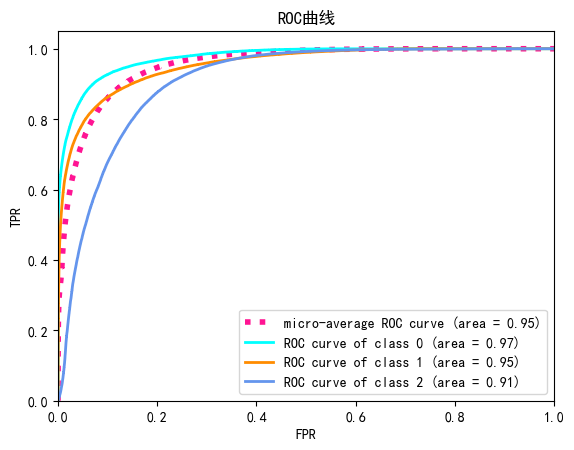

In [309]:
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


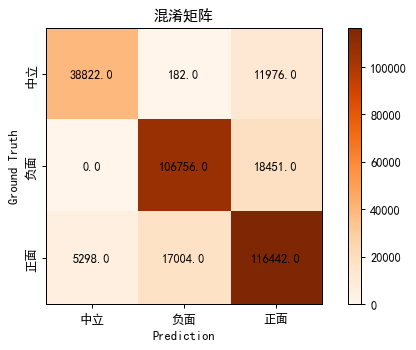

In [310]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.family']='sans-serif'  # 解决绘图中文乱码
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示为框

# 混淆矩阵
classes = ['中立','负面','正面']

confusion_matrix = model_LR.pred_table()

plt.figure(figsize=(6, 4), dpi=90)

plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Oranges)  #按照像素显示出矩阵
plt.title('混淆矩阵')
plt.colorbar()

tick_marks = np.arange(3)
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes, rotation=90,verticalalignment='center')

for x in range(len(confusion_matrix)):
    for y in range(len(confusion_matrix)):
        plt.annotate(confusion_matrix[y,x], xy = (x,y), horizontalalignment = 'center', verticalalignment = 'center')

plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()


In [311]:
# # 手动微调参数以得到更稳健的模型
# from sklearn.model_selection import GridSearchCV
# parameters_lr = [{'penalty':['l1','l2'],'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}]
# grid_search_lr = GridSearchCV(estimator = classifier7,
#                            param_grid = parameters_lr,
#                            scoring = 'accuracy',
#                            cv = 10,
#                            n_jobs = -1)
# grid_search_lr.fit(X_train, y_train)
# best_accuracy_lr = grid_search_lr.best_score_
# best_paramaeter_lr = grid_search_lr.best_params_  
# print("Best Accuracy of LR: {:.2f} %".format(best_accuracy_lr.mean()*100))
# print("Best Parameter of LR:", best_paramaeter_lr)


# 使用DID模型
- 参考：https://blog.csdn.net/mfsdmlove/article/details/126614239

In [301]:
# # import wooldridge as woo
# import pandas as pd
# import statsmodels.formula.api as smf

# # kielmc = woo.dataWoo('kielmc')
# # import wooldridge as woo
# import pandas as pd
# import statsmodels.formula.api as smf

# # kielmc = woo.dataWoo('kielmc')

# # DID模型
# reg_did = smf.ols(formula='sentiment_score ~ outbreak * C(comment_time)', data= df1)
# results_did = reg_did.fit()
# print(results_did.summary())

# # # DiD模型：加入控制变量
# # reg_didC = smf.ols(formula='rprice ~ nearinc * C(year) + age +I(age**2)',data=kielmc)
# # results_didC = reg_didC.fit()
# # print(results_didC.summary())


# # 'scence_id', 'outbreak', 'high_temperature','holiday', 'period', 'month','weather_point','sentiment_type

MemoryError: Unable to allocate 6.15 GiB for an array with shape (2620, 314935) and data type float64

In [312]:
df2.to_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\逻辑回归-微博层面数据.csv',encoding = 'utf-8-sig')

## 时间段period划分 excel的折线图，根据感染人数进行划分

# 看不同period的逻辑回归结果

In [1]:
import pandas as pd
# df1 = pd.read_csv('E:\\论文\\第二篇论文\\截止到2023年2月数据汇总\\面板-结构化数据.csv',encoding = 'utf-8-sig')
df2

,comment_time,scence_id,Unnamed: 0,outbreak,holiday,period,month,temperature_1,weather_point,sentiment_type,sentiment_score,previous_sentiment_score,previous_sentiment_score2,MA2_sentiment_score,MA3_sentiment_score
0,2022/10/18,0,13,1,0,5,10,0.642857,0.00,0.900000,0.648577,0.491824,0.612702,0.570200,0.584367
1,2022/10/19,0,14,1,0,5,10,0.685714,0.00,1.300000,0.626718,0.648577,0.491824,0.637647,0.589039
2,2022/10/2,0,15,1,1,5,10,0.857143,0.00,1.102041,0.671145,0.626718,0.648577,0.648931,0.648813
3,2022/10/20,0,16,1,0,5,10,0.700000,0.00,1.166667,0.764024,0.671145,0.626718,0.717585,0.687296
4,2022/10/21,0,17,1,0,5,10,0.757143,0.00,1.444444,0.691298,0.764024,0.671145,0.727661,0.708823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91830,2022/9/5,272,91843,1,0,5,9,0.671429,0.16,1.066667,0.654968,0.556580,0.702336,0.605774,0.637961
91831,2022/9/6,272,91844,1,0,5,9,0.771429,0.00,0.200000,0.421901,0.654968,0.556580,0.538434,0.544483
91832,2022/9/7,272,91845,1,0,5,9,0.814286,0.00,0.500000,0.556592,0.421901,0.654968,0.489247,0.544487
91833,2022/9/8,272,91846,1,0,5,9,0.785714,0.00,0.631579,0.633952,0.556592,0.421901,0.595272,0.537482


In [313]:
df2['period'].value_counts()

5    111803
4    109034
2     29456
0     27738
3     26675
6      6043
1      4182
Name: period, dtype: int64

In [6]:
df2 = df2.set_index(['comment_time','scence_id'])

In [314]:
df_period_0 = df2[df2['period']==0]
df_period_1 = df2[df2['period']==1]
df_period_2 = df2[df2['period']==2]
df_period_3 = df2[df2['period']==3]
df_period_4 = df2[df2['period']==4]
df_period_5 =  df2[df2['period']==5]
df_period_6 =  df2[df2['period']==6]
# df_period_0

## period_0的逻辑回归

In [315]:
# 划分X和y
import numpy as np
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_0[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_0[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_0['sentiment_type']).astype('int')


In [316]:
# 模型结果查看
from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

         Current function value: 0.407601
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


,0,1
temperature_1,-13.278771,-5.955927
holiday,0.205281,0.137219
month,-0.607057,-0.280792
weather_point,-2.375220,-1.116516
previous_sentiment_score,-37.373565,-21.490207
previous_sentiment_score2,-11.805060,-6.495756
MA2_sentiment_score,50.891121,29.919010
MA3_sentiment_score,29.992378,17.780766


In [317]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                       MNLogit                  Pseudo R-squared:         0.598     
Dependent Variable:          y                        AIC:                      22644.0863
Date:                        2023-04-15 22:06         BIC:                      22775.7752
No. Observations:            27738                    Log-Likelihood:           -11306.   
Df Model:                    14                       LL-Null:                  -28133.   
Df Residuals:                27722                    LLR p-value:              0.0000    
Converged:                   0.0000                   Scale:                    1.0000    
No. Iterations:              35.0000                                                      
------------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1 -13.2788       0.2357 -56.3397 0.0000      -13.7407     -12.8168
                  holiday   0.2053       0.1029   1.9953 0.0460        0.0036       0.4069
                    month  -0.6071       0.0158 -38.4203 0.0000       -0.6380      -0.5761
            weather_point  -2.3752       0.2896  -8.2019 0.0000       -2.9428      -1.8076
 previous_sentiment_score -37.3736       0.4545 -82.2254 0.0000      -38.2644     -36.4827
previous_sentiment_score2 -11.8051  440545.0272  -0.0000 1.0000  -863464.1920  863440.5819
      MA2_sentiment_score  50.8911  881020.3418   0.0001 1.0000 -1726717.2485 1726819.0308
      MA3_sentiment_score  29.9924 1321563.0068   0.0000 1.0000 -2590185.9043 2590245.8891
------------------------------------------------------------------------------------------
          y = 1             Coef.     Std.Err.     t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1   -5.9559      0.1980 -30.0802 0.0000       -6.3440      -5.5679
                  holiday    0.1372      0.0865   1.5864 0.1126       -0.0323       0.3067
                    month   -0.2808      0.0137 -20.4422 0.0000       -0.3077      -0.2539
            weather_point   -1.1165      0.2368  -4.7144 0.0000       -1.5807      -0.6523
 previous_sentiment_score  -21.4902      0.3935 -54.6104 0.0000      -22.2615     -20.7189
previous_sentiment_score2   -6.4958 316078.7095  -0.0000 1.0000  -619509.3826  619496.3911
      MA2_sentiment_score   29.9190 632157.4189   0.0000 1.0000 -1238975.8547 1239035.6927
      MA3_sentiment_score   17.7808 948236.1284   0.0000 1.0000 -1858490.8797 1858526.4413
==========================================================================================

"""

In [318]:
# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)

Precision_score: 0.836577979666883
Recall_score: 0.836577979666883
F1_score: 0.836577979666883


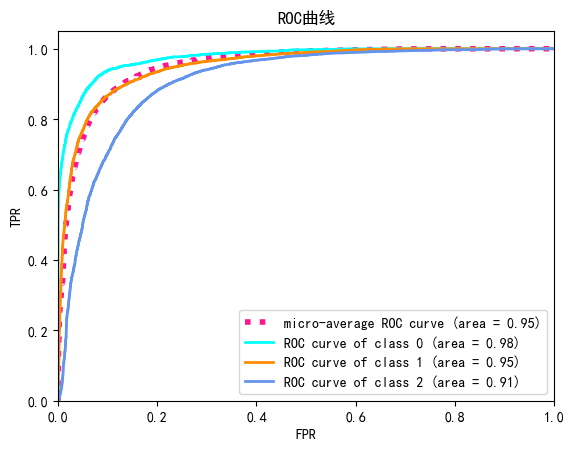

In [319]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()

# period_1

In [322]:
# 划分X和y
import numpy as np
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_1[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_1[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_1['sentiment_type']).astype('int')


from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

         Current function value: 0.443591
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-19.659249,-7.660094
holiday,-1.739322,-0.651594
month,-0.198984,-0.069509
weather_point,-1.387627,-0.689398
previous_sentiment_score,-34.107048,-18.152149
previous_sentiment_score2,-10.654662,-5.616311
MA2_sentiment_score,45.097600,24.513875
MA3_sentiment_score,26.513510,14.470479


In [323]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                        MNLogit                  Pseudo R-squared:         0.575    
Dependent Variable:           y                        AIC:                      3742.1939
Date:                         2023-04-15 22:07         BIC:                      3843.6106
No. Observations:             4182                     Log-Likelihood:           -1855.1  
Df Model:                     14                       LL-Null:                  -4368.6  
Df Residuals:                 4166                     LLR p-value:              0.0000   
Converged:                    0.0000                   Scale:                    1.0000   
No. Iterations:               35.0000                                                     
------------------------------------------------------------------------------------------
          y = 0               Coef.     Std.Err.      t       P>|t|     [0.025     0.975] 
------------------------------------------------------------------------------------------
            temperature_1    -19.6592     0.8496   -23.1400   0.0000   -21.3244   -17.9941
                  holiday     -1.7393     0.2208    -7.8791   0.0000    -2.1720    -1.3067
                    month     -0.1990     0.1037    -1.9184   0.0551    -0.4023     0.0043
            weather_point     -1.3876     0.8555    -1.6219   0.1048    -3.0645     0.2892
 previous_sentiment_score    -34.1070     1.0229   -33.3440   0.0000   -36.1119   -32.1022
previous_sentiment_score2    -10.6547        nan        nan      nan        nan        nan
      MA2_sentiment_score     45.0976        nan        nan      nan        nan        nan
      MA3_sentiment_score     26.5135        nan        nan      nan        nan        nan
------------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1  -7.6601       0.6375 -12.0156 0.0000       -8.9096      -6.4106
                  holiday  -0.6516       0.1766  -3.6894 0.0002       -0.9977      -0.3054
                    month  -0.0695       0.0844  -0.8231 0.4105       -0.2350       0.0960
            weather_point  -0.6894       0.6683  -1.0316 0.3023       -1.9992       0.6204
 previous_sentiment_score -18.1521       0.8291 -21.8930 0.0000      -19.7772     -16.5271
previous_sentiment_score2  -5.6163  809596.0516  -0.0000 1.0000 -1586784.7194 1586773.4868
      MA2_sentiment_score  24.5139 1619192.1032   0.0000 1.0000 -3173533.6924 3173582.7201
      MA3_sentiment_score  14.4705 2428788.1547   0.0000 1.0000 -4760322.8389 4760351.7798
==========================================================================================

"""

In [324]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)


Precision_score: 0.8106169296987088
Recall_score: 0.8106169296987088
F1_score: 0.8106169296987087


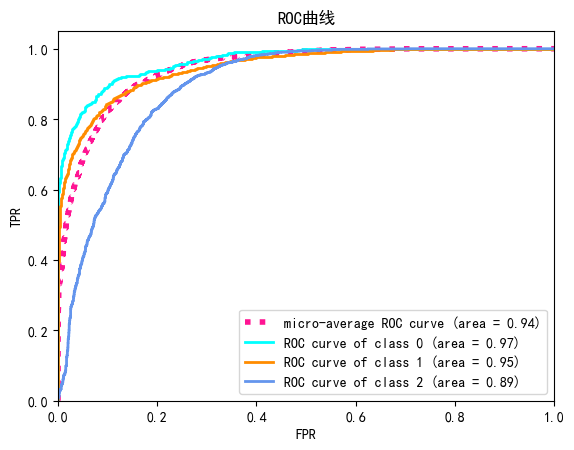

In [325]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()

# period_2

In [326]:
# 划分X和y
import numpy as np
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_2[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_2[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_2['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


Optimization terminated successfully.
         Current function value: 0.351241
         Iterations 30


,0,1
temperature_1,-17.882245,-6.686606
holiday,-0.679431,-0.260289
month,-0.739228,-0.294879
weather_point,-0.343163,-0.653175
previous_sentiment_score,-41.192376,-21.321222
previous_sentiment_score2,-12.336499,-6.260690
MA2_sentiment_score,57.618789,30.182439
MA3_sentiment_score,34.300358,18.034726


In [327]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                      Results: MNLogit
============================================================================================
Model:                       MNLogit                   Pseudo R-squared:          0.659     
Dependent Variable:          y                         AIC:                       20724.2908
Date:                        2023-04-15 22:07          BIC:                       20856.9412
No. Observations:            29456                     Log-Likelihood:            -10346.   
Df Model:                    14                        LL-Null:                   -30364.   
Df Residuals:                29440                     LLR p-value:               0.0000    
Converged:                   1.0000                    Scale:                     1.0000    
No. Iterations:              30.0000                                                        
--------------------------------------------------------------------------------------------
           y = 0             Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
--------------------------------------------------------------------------------------------
            temperature_1   -17.8822       0.2751 -65.0026 0.0000      -18.4214     -17.3431
                  holiday    -0.6794       0.0931  -7.2987 0.0000       -0.8619      -0.4970
                    month    -0.7392       0.0180 -41.0333 0.0000       -0.7745      -0.7039
            weather_point    -0.3432       0.2427  -1.4142 0.1573       -0.8188       0.1324
 previous_sentiment_score   -41.1924       0.4682 -87.9804 0.0000      -42.1100     -40.2747
previous_sentiment_score2   -12.3365 1476288.2395  -0.0000 1.0000 -2893484.1167 2893459.4437
      MA2_sentiment_score    57.6188 2554096.8364   0.0000 1.0000 -5005880.1936 5005995.4312
      MA3_sentiment_score    34.3004 3612038.3857   0.0000 1.0000 -7079430.8464 7079499.4471
--------------------------------------------------------------------------------------------
          y = 1            Coef.     Std.Err.      t     P>|t|      [0.025         0.975]   
--------------------------------------------------------------------------------------------
            temperature_1  -6.6866       0.2039 -32.7981 0.0000        -7.0862       -6.2870
                  holiday  -0.2603       0.0743  -3.5029 0.0005        -0.4059       -0.1147
                    month  -0.2949       0.0144 -20.4102 0.0000        -0.3232       -0.2666
            weather_point  -0.6532       0.1879  -3.4755 0.0005        -1.0215       -0.2848
 previous_sentiment_score -21.3212       0.3722 -57.2888 0.0000       -22.0507      -20.5918
previous_sentiment_score2  -6.2607 1702731.2243  -0.0000 1.0000  -3337298.1356  3337285.6143
      MA2_sentiment_score  30.1824 3405462.4486   0.0000 1.0000  -6674553.5674  6674613.9323
      MA3_sentiment_score  18.0347 5108193.6728   0.0000 1.0000 -10011857.5901 10011893.6596
============================================================================================

"""

In [328]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)


Precision_score: 0.8491648560564911
Recall_score: 0.8491648560564911
F1_score: 0.849164856056491


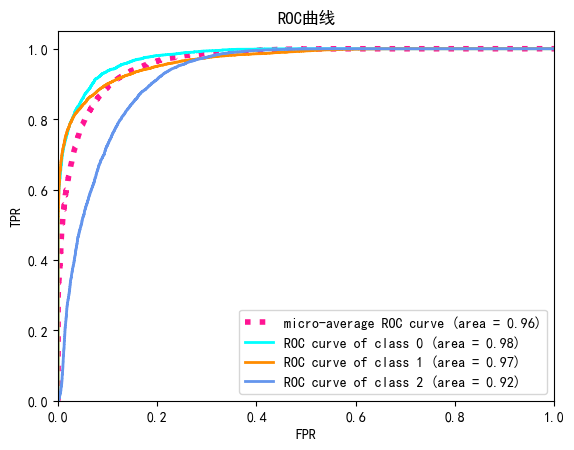

In [329]:
# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


## period_3

In [330]:
# 划分X和y
import numpy as np
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_3[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_3[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_3['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.444716
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-16.218380,-7.283504
holiday,-0.741726,-0.142657
month,-0.267532,-0.124538
weather_point,0.444382,0.472637
previous_sentiment_score,-34.963745,-19.961477
previous_sentiment_score2,-11.874975,-6.536382
MA2_sentiment_score,45.880005,26.989442
MA3_sentiment_score,26.628328,15.814170


In [331]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                     Results: MNLogit
==========================================================================================
Model:                       MNLogit                  Pseudo R-squared:         0.565     
Dependent Variable:          y                        AIC:                      23757.6246
Date:                        2023-04-15 22:07         BIC:                      23888.6883
No. Observations:            26675                    Log-Likelihood:           -11863.   
Df Model:                    14                       LL-Null:                  -27291.   
Df Residuals:                26659                    LLR p-value:              0.0000    
Converged:                   0.0000                   Scale:                    1.0000    
No. Iterations:              35.0000                                                      
------------------------------------------------------------------------------------------
          y = 0            Coef.     Std.Err.      t     P>|t|      [0.025       0.975]   
------------------------------------------------------------------------------------------
            temperature_1 -16.2184       0.2565 -63.2316 0.0000      -16.7211     -15.7157
                  holiday  -0.7417       0.0845  -8.7743 0.0000       -0.9074      -0.5760
                    month  -0.2675       0.0103 -26.0045 0.0000       -0.2877      -0.2474
            weather_point   0.4444       0.3425   1.2974 0.1945       -0.2269       1.1157
 previous_sentiment_score -34.9637       0.4382 -79.7947 0.0000      -35.8225     -34.1049
previous_sentiment_score2 -11.8750  412701.3935  -0.0000 1.0000  -808891.7426  808867.9927
      MA2_sentiment_score  45.8800  821783.9764   0.0001 1.0000 -1610621.1168 1610712.8768
      MA3_sentiment_score  26.6283 1215434.8922   0.0000 1.0000 -2382181.9859 2382235.2425
------------------------------------------------------------------------------------------
          y = 1               Coef.     Std.Err.      t       P>|t|     [0.025     0.975] 
------------------------------------------------------------------------------------------
            temperature_1     -7.2835     0.2100   -34.6774   0.0000    -7.6952    -6.8718
                  holiday     -0.1427     0.0709    -2.0110   0.0443    -0.2817    -0.0036
                    month     -0.1245     0.0087   -14.2456   0.0000    -0.1417    -0.1074
            weather_point      0.4726     0.2819     1.6768   0.0936    -0.0798     1.0251
 previous_sentiment_score    -19.9615     0.3810   -52.3928   0.0000   -20.7082   -19.2147
previous_sentiment_score2     -6.5364        nan        nan      nan        nan        nan
      MA2_sentiment_score     26.9894        nan        nan      nan        nan        nan
      MA3_sentiment_score     15.8142        nan        nan      nan        nan        nan
==========================================================================================

"""

In [332]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.811958762886598
Recall_score: 0.811958762886598
F1_score: 0.811958762886598


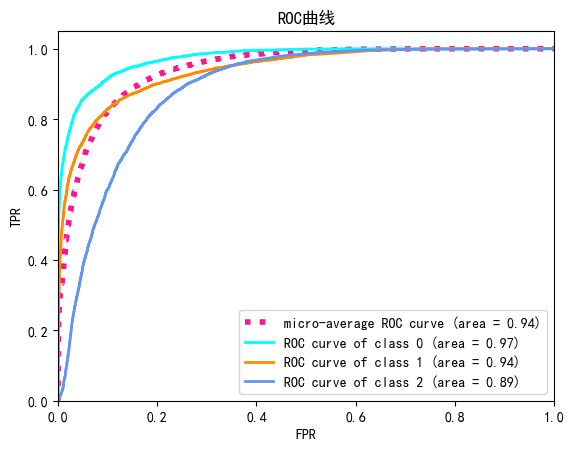

In [333]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


# period_4

In [334]:
# 划分X和y
import numpy as np
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_4[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_4[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_4['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


         Current function value: 0.446075
         Iterations: 35


D:\python\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-13.157953,-5.717643
holiday,-1.171087,-0.417178
month,-0.188289,-0.094207
weather_point,-0.773237,-0.188473
previous_sentiment_score,-34.175381,-19.449373
previous_sentiment_score2,-11.837168,-6.409575
MA2_sentiment_score,44.871041,26.297939
MA3_sentiment_score,25.968304,15.395419


In [335]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: MNLogit
==============================================================================
Model:                  MNLogit              Pseudo R-squared:     0.564      
Dependent Variable:     y                    AIC:                  97306.6456 
Date:                   2023-04-15 22:07     BIC:                  97460.2362 
No. Observations:       109034               Log-Likelihood:       -48637.    
Df Model:               14                   LL-Null:              -1.1146e+05
Df Residuals:           109018               LLR p-value:          0.0000     
Converged:              0.0000               Scale:                1.0000     
No. Iterations:         35.0000                                               
------------------------------------------------------------------------------
          y = 0            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1 -13.1580   0.1163 -113.1341 0.0000 -13.3859 -12.9300
                  holiday  -1.1711   0.0531  -22.0693 0.0000  -1.2751  -1.0671
                    month  -0.1883   0.0077  -24.3012 0.0000  -0.2035  -0.1731
            weather_point  -0.7732   0.1238   -6.2454 0.0000  -1.0159  -0.5306
 previous_sentiment_score -34.1754   0.2088 -163.6375 0.0000 -34.5847 -33.7660
previous_sentiment_score2 -11.8372      nan       nan    nan      nan      nan
      MA2_sentiment_score  44.8710      nan       nan    nan      nan      nan
      MA3_sentiment_score  25.9683      nan       nan    nan      nan      nan
------------------------------------------------------------------------------
          y = 1            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1  -5.7176   0.0970  -58.9394 0.0000  -5.9078  -5.5275
                  holiday  -0.4172   0.0448   -9.3198 0.0000  -0.5049  -0.3294
                    month  -0.0942   0.0069  -13.6983 0.0000  -0.1077  -0.0807
            weather_point  -0.1885   0.1020   -1.8484 0.0645  -0.3883   0.0114
 previous_sentiment_score -19.4494   0.1806 -107.6718 0.0000 -19.8034 -19.0953
previous_sentiment_score2  -6.4096      nan       nan    nan      nan      nan
      MA2_sentiment_score  26.2979      nan       nan    nan      nan      nan
      MA3_sentiment_score  15.3954      nan       nan    nan      nan      nan
==============================================================================

"""

In [336]:

# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.8090962452079168
Recall_score: 0.8090962452079168
F1_score: 0.8090962452079167


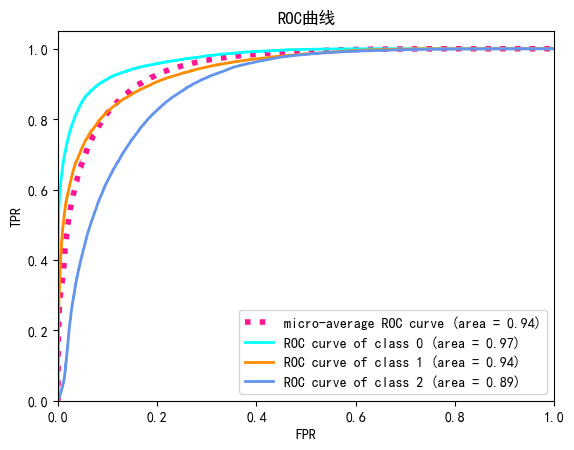

In [337]:

# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


# period_5

In [338]:
# 划分X和y
import numpy as np
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_5[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_5[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_5['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数


Optimization terminated successfully.
         Current function value: 0.314460
         Iterations 25


D:\python\lib\site-packages\statsmodels\discrete\discrete_model.py:4247: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diag(self.cov_params()))


,0,1
temperature_1,-11.544629,-4.217443
holiday,0.400237,0.167998
month,-1.325499,-0.500264
weather_point,-2.033134,-0.630089
previous_sentiment_score,-43.533148,-22.536611
previous_sentiment_score2,-12.828607,-6.660512
MA2_sentiment_score,61.538508,32.105943
MA3_sentiment_score,36.749459,19.183788


In [339]:
#  查看模型结果
model_LR.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                               Results: MNLogit
==============================================================================
Model:                  MNLogit              Pseudo R-squared:     0.692      
Dependent Variable:     y                    AIC:                  70347.1059 
Date:                   2023-04-15 22:07     BIC:                  70501.0978 
No. Observations:       111803               Log-Likelihood:       -35158.    
Df Model:               14                   LL-Null:              -1.1414e+05
Df Residuals:           111787               LLR p-value:          0.0000     
Converged:              1.0000               Scale:                1.0000     
No. Iterations:         25.0000                                               
------------------------------------------------------------------------------
          y = 0            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1 -11.5446   0.1350  -85.5086 0.0000 -11.8092 -11.2800
                  holiday   0.4002   0.0540    7.4139 0.0000   0.2944   0.5060
                    month  -1.3255   0.0119 -111.7754 0.0000  -1.3487  -1.3023
            weather_point  -2.0331   0.1981  -10.2608 0.0000  -2.4215  -1.6448
 previous_sentiment_score -43.5331   0.2545 -171.0594 0.0000 -44.0319 -43.0344
previous_sentiment_score2 -12.8286      nan       nan    nan      nan      nan
      MA2_sentiment_score  61.5385      nan       nan    nan      nan      nan
      MA3_sentiment_score  36.7495      nan       nan    nan      nan      nan
------------------------------------------------------------------------------
          y = 1            Coef.   Std.Err.     t     P>|t|   [0.025   0.975] 
------------------------------------------------------------------------------
            temperature_1  -4.2174   0.1041  -40.5169 0.0000  -4.4215  -4.0134
                  holiday   0.1680   0.0430    3.9092 0.0001   0.0838   0.2522
                    month  -0.5003   0.0089  -56.2176 0.0000  -0.5177  -0.4828
            weather_point  -0.6301   0.1568   -4.0190 0.0001  -0.9374  -0.3228
 previous_sentiment_score -22.5366   0.2027 -111.1964 0.0000 -22.9338 -22.1394
previous_sentiment_score2  -6.6605      nan       nan    nan      nan      nan
      MA2_sentiment_score  32.1059      nan       nan    nan      nan      nan
      MA3_sentiment_score  19.1838      nan       nan    nan      nan      nan
==============================================================================

"""

In [340]:
# 逻辑回归模型评价
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize 
from itertools import cycle

# Precision Recall 和 F1
nb_classes = 3          # 设置分类数

y_pred = model_LR.predict()      # 自我预测，得到预测为各类的概率
y_pred_max = [np.argmax(y) for y in y_pred]   # 取出y中元素最大值所对应的索引
y_true = y

y_pred_b = label_binarize(y_pred_max, classes=[i for i in range(nb_classes)])    # binarize the output
y_true_b = label_binarize(y_true, classes=[i for i in range(nb_classes)])    # binarize the output

precision = precision_score(y_true_b, y_pred_b, average='micro')
recall = recall_score(y_true_b, y_pred_b, average='micro')
f1_score = f1_score(y_true_b, y_pred_b, average='micro')

print("Precision_score:",precision)
print("Recall_score:",recall)
print("F1_score:",f1_score)



Precision_score: 0.8657549439639366
Recall_score: 0.8657549439639366
F1_score: 0.8657549439639366


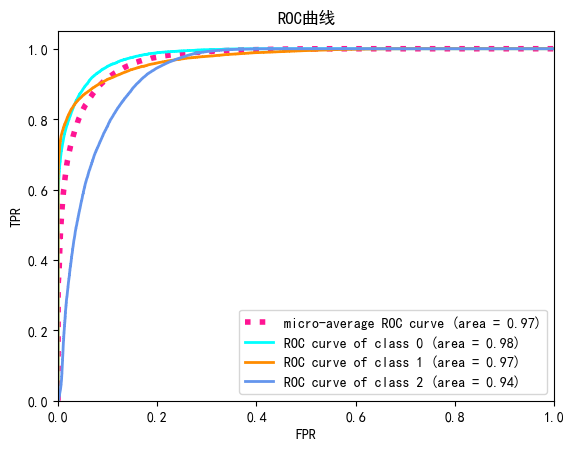

In [341]:
# ROC与AUC
import matplotlib.pyplot as plt

Y_valid = y_true_b
Y_pred = model_LR.predict()  # 用预测的概率值，不然ROC是折线的形式

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nb_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_valid[:, i], Y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_valid.ravel(), Y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

lw = 2
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
  label='micro-average ROC curve (area = {0:0.2f})'
  ''.format(roc_auc["micro"]),
  color='deeppink', linestyle=':', linewidth=4)


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])  # 几个类别就设置几个颜色
for i, color in zip(range(nb_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
    label='ROC curve of class {0} (area = {1:0.2f})'
    ''.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=lw)    # 斜着的分界线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC曲线')
plt.legend(loc="lower right")
# plt.savefig("../images/ROC/ROC_3分类.png")
plt.show()


## period_6

In [342]:
# 划分X和y
import numpy as np
# X = df_period_6[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point']]
X = df_period_6[['temperature_1', 'holiday', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2','MA2_sentiment_score','MA3_sentiment_score']]
# X = df_period_6[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score','previous_sentiment_score2']]
# X = df_period_6[['outbreak','temperature_1', 'holiday', 'period', 'month','weather_point','previous_sentiment_score']]

y = np.array(df_period_6['sentiment_type']).astype('int')

from statsmodels.discrete.discrete_model import MNLogit
model_LR = MNLogit(y,X,missing='drop').fit()
model_LR.summary()	# 查看结果
model_LR.params		# 查看参数的系数

Optimization terminated successfully.
         Current function value: 0.300974
         Iterations 12


LinAlgError: Singular matrix

In [47]:
df_p6 = df1[df1['period']==6].to_
df_p6
# df_p6['comment_time'].describe()

,,Unnamed: 0,outbreak,holiday,period,month,temperature_1,weather_point,sentiment_type,sentiment_score,previous_sentiment_score,previous_sentiment_score2,MA2_sentiment_score,MA3_sentiment_score
comment_time,scence_id,,,,,,,,,,,,,
2022/12/10,1,239,1,0,6,12,0.600000,0.00,0.333333,0.587908,0.749664,0.677638,0.668786,0.671737
2022/12/11,1,240,1,0,6,12,0.542857,0.00,0.833333,0.644877,0.587908,0.749664,0.616393,0.660816
2022/12/12,1,241,1,0,6,12,0.557143,0.00,1.416667,0.671985,0.644877,0.587908,0.658431,0.634923
2022/12/13,1,242,1,0,6,12,0.557143,0.00,0.818182,0.546613,0.671985,0.644877,0.609299,0.621158
2022/12/14,1,243,1,0,6,12,0.585714,0.00,0.500000,0.410648,0.546613,0.671985,0.478631,0.543082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022/12/30,272,91673,1,0,6,12,0.442857,0.00,0.250000,0.386876,0.999602,0.456437,0.693239,0.614305
2022/12/31,272,91674,1,0,6,12,0.471429,0.00,1.000000,0.572879,0.386876,0.999602,0.479877,0.653119
2022/12/6,272,91677,1,0,6,12,0.500000,0.00,1.000000,0.350562,0.503503,0.251545,0.427033,0.368537
